## Libraries

In [59]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import soundfile as sf
warnings.filterwarnings('ignore')
%matplotlib inline

In [60]:
# !pip install pysoundfile

In [61]:
sound_database_path = 'Respiratory_Sound_Database/Respiratory_Sound_Database'

os.listdir(sound_database_path)

['audio_and_txt_files',
 'filename_differences.txt',
 'filename_format.txt',
 'patient_diagnosis.csv']

## Read files

a. Read demographic_info.txt file

In [62]:
col_names = ['patient_id', 'age', 'sex', 'adult_bmi', 'child_weight', 'child_height']

df_demographics = pd.read_csv('demographic_info.txt', names=col_names, delimiter=' ')

df_demographics.head(10)

,patient_id,age,sex,adult_bmi,child_weight,child_height
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0
5,106,73.00,F,21.00,NaN,NaN
6,107,75.00,F,33.70,NaN,NaN
7,108,3.00,M,NaN,NaN,NaN
8,109,84.00,F,33.53,NaN,NaN
9,110,75.00,M,25.21,NaN,NaN


b. Read patient_diagnosis.csv file

In [63]:
df_patient = pd.read_csv('Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv', names=['patient_id', 'diagnosis'])

df_patient.head(10)

,patient_id,diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI
5,106,COPD
6,107,COPD
7,108,LRTI
8,109,COPD
9,110,COPD


c. Read filename_differences.txt file

In [64]:
df_format = pd.read_csv('Respiratory_Sound_Database/Respiratory_Sound_Database/filename_differences.txt',names=['filename'])


df_format.head(10)

,filename
0,'101_1b1_Al_sc_AKGC417L'
1,'101_1b1_Pr_sc_AKGC417L'
2,'102_1b1_Ar_sc_AKGC417L'
3,'105_1b1_Tc_sc_LittC2SE'
4,'108_1b1_Al_sc_LittC2SE'
5,'111_1b2_Tc_sc_LittC2SE'
6,'111_1b3_Tc_sc_LittC2SE'
7,'115_1b1_Ar_sc_LittC2SE'
8,'116_1b2_Pl_sc_LittC2SE'
9,'116_1b2_Tc_sc_LittC2SE'


List audio and annotation files

In [65]:
audio_path = 'Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files'

print(f'Number of files (audio + annotation): {len(os.listdir(audio_path))}')
print(os.listdir(audio_path))

Number of files (audio + annotation): 1840
['101_1b1_Al_sc_Meditron.txt', '101_1b1_Al_sc_Meditron.wav', '101_1b1_Pr_sc_Meditron.txt', '101_1b1_Pr_sc_Meditron.wav', '102_1b1_Ar_sc_Meditron.txt', '102_1b1_Ar_sc_Meditron.wav', '103_2b2_Ar_mc_LittC2SE.txt', '103_2b2_Ar_mc_LittC2SE.wav', '104_1b1_Al_sc_Litt3200.txt', '104_1b1_Al_sc_Litt3200.wav', '104_1b1_Ar_sc_Litt3200.txt', '104_1b1_Ar_sc_Litt3200.wav', '104_1b1_Ll_sc_Litt3200.txt', '104_1b1_Ll_sc_Litt3200.wav', '104_1b1_Lr_sc_Litt3200.txt', '104_1b1_Lr_sc_Litt3200.wav', '104_1b1_Pl_sc_Litt3200.txt', '104_1b1_Pl_sc_Litt3200.wav', '104_1b1_Pr_sc_Litt3200.txt', '104_1b1_Pr_sc_Litt3200.wav', '105_1b1_Tc_sc_Meditron.txt', '105_1b1_Tc_sc_Meditron.wav', '106_2b1_Pl_mc_LittC2SE.txt', '106_2b1_Pl_mc_LittC2SE.wav', '106_2b1_Pr_mc_LittC2SE.txt', '106_2b1_Pr_mc_LittC2SE.wav', '107_2b3_Al_mc_AKGC417L.txt', '107_2b3_Al_mc_AKGC417L.wav', '107_2b3_Ar_mc_AKGC417L.txt', '107_2b3_Ar_mc_AKGC417L.wav', '107_2b3_Ll_mc_AKGC417L.txt', '107_2b3_Ll_mc_AKGC417L.wa

## Create Spectogram

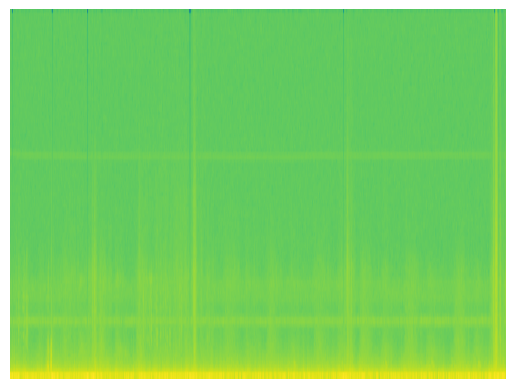

10000


In [66]:
# helper functions
def load_wav_info(wav_file):
    data, samplerate = sf.read(wav_file)
    return data, samplerate

def spectogram(data, samplerate):
    plt.specgram(data, NFFT=200, Fs=samplerate, noverlap=128, cmap='viridis')
    # Removed the colorbar line
    plt.axis('off') # turn off axis
    plt.show()

def plot_wave(data):
    plt.plot(data)
    plt.show()

def plot_wave_spectogram(wav_file):
    data, sample_rate = load_wav_info(wav_file)
    # plot_wave(data)
    spectogram(data, sample_rate)
    print(sample_rate)

# plot sample wave and spectogram
wav_file = 'Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/223_1b1_Pr_sc_Meditron.wav'
plot_wave_spectogram(wav_file)

Make all the .wav audio files into a spectogram

In [67]:
spectogram_path = 'spectogram_image'

def save_spectogram(wav_file, save_path):
    data, sample_rate = load_wav_info(wav_file)
    plt.specgram(data, NFFT=200, Fs=sample_rate, noverlap=128, cmap='viridis')
    plt.axis('off')
    plt.savefig(save_path)
    plt.close()

# create a folder to save the spectogram images
if not os.path.exists(spectogram_path):
    os.makedirs(spectogram_path)

# save all the spectogram images
for file in os.listdir(audio_path):
    if file.endswith('.wav'):
        file_path = os.path.join(audio_path, file)
        save_path = os.path.join(spectogram_path, file.replace('.wav', '.png'))
        save_spectogram(file_path, save_path)

# check the saved spectogram images
print(f'Number of saved spectogram images: {len(os.listdir(spectogram_path))}')
print(os.listdir(spectogram_path))

Number of saved spectogram images: 920
['101_1b1_Al_sc_Meditron.png', '101_1b1_Pr_sc_Meditron.png', '102_1b1_Ar_sc_Meditron.png', '103_2b2_Ar_mc_LittC2SE.png', '104_1b1_Al_sc_Litt3200.png', '104_1b1_Ar_sc_Litt3200.png', '104_1b1_Ll_sc_Litt3200.png', '104_1b1_Lr_sc_Litt3200.png', '104_1b1_Pl_sc_Litt3200.png', '104_1b1_Pr_sc_Litt3200.png', '105_1b1_Tc_sc_Meditron.png', '106_2b1_Pl_mc_LittC2SE.png', '106_2b1_Pr_mc_LittC2SE.png', '107_2b3_Al_mc_AKGC417L.png', '107_2b3_Ar_mc_AKGC417L.png', '107_2b3_Ll_mc_AKGC417L.png', '107_2b3_Lr_mc_AKGC417L.png', '107_2b3_Pl_mc_AKGC417L.png', '107_2b3_Pr_mc_AKGC417L.png', '107_2b3_Tc_mc_AKGC417L.png', '107_2b4_Al_mc_AKGC417L.png', '107_2b4_Ar_mc_AKGC417L.png', '107_2b4_Ll_mc_AKGC417L.png', '107_2b4_Lr_mc_AKGC417L.png', '107_2b4_Pl_mc_AKGC417L.png', '107_2b4_Pr_mc_AKGC417L.png', '107_2b4_Tc_mc_AKGC417L.png', '107_2b5_Al_mc_AKGC417L.png', '107_2b5_Ar_mc_AKGC417L.png', '107_2b5_Ll_mc_AKGC417L.png', '107_2b5_Lr_mc_AKGC417L.png', '107_2b5_Pl_mc_AKGC417L.png', 

Annotation files

The annotation text files have four columns:
- Beginning of respiratory cycle(s)
- End of respiratory cycle(s)
- Presence/absence of crackles (presence=1, absence=0)
- Presence/absence of wheezes (presence=1, absence=0)

In [ ]:
# join patient and image path
df_format['filename'] = df_format['filename'].apply(lambda x: x.replace('.txt', '.png'))
df_format['filename'] = df_format['filename'].apply(lambda x: x.replace('_text', ''))
df_format['filename'] = df_format['filename'].apply(lambda x: x.replace(' ', ''))

# join df_patient and spectogram

,filename
0,'101_1b1_Al_sc_AKGC417L'
1,'101_1b1_Pr_sc_AKGC417L'
2,'102_1b1_Ar_sc_AKGC417L'
3,'105_1b1_Tc_sc_LittC2SE'
4,'108_1b1_Al_sc_LittC2SE'
5,'111_1b2_Tc_sc_LittC2SE'
6,'111_1b3_Tc_sc_LittC2SE'
7,'115_1b1_Ar_sc_LittC2SE'
8,'116_1b2_Pl_sc_LittC2SE'
9,'116_1b2_Tc_sc_LittC2SE'


In [71]:
len(df_patient)

126